In [2]:
import numpy as np
import scipy
import sklearn

In [3]:
def split_db_2to1(D, L, seed=0):
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DVAL = D[:, idxTest]
    LTR = L[idxTrain]
    LVAL = L[idxTest]
    return (DTR, LTR), (DVAL, LVAL)

In [4]:
dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)


In [5]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=getCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]

In [6]:
def logpdf_GAU_ND(x, mu, C):
    M=x.shape[0]
    XC = x - mu
    sign, logdet = np.linalg.slogdet(C)
    invC = np.linalg.inv(C)
    quad = np.sum(XC * (invC @ XC), axis=0)
    return -0.5 * (M * np.log(2*np.pi) + logdet + quad)


def logpdf_GMM(X,gmm):
    n_cluster=len(gmm)
    S=np.zeros((n_cluster,X.shape[1]))
    
    for g in range(n_cluster):
        w=gmm[g][0]
        mu=gmm[g][1]
        C=gmm[g][2]
        S[g, :] = logpdf_GAU_ND(X, mu, C) + np.log(w)
    
    logdens = scipy.special.logsumexp(S, axis=0)
    return S,logdens

In [7]:
def EM_constrained(threshold,X,gmm,psi):
    
    actual_gmm=gmm
    N=X.shape[1]
    
    #E Step
    # Calcolo la probabilità a posteriori (responsability) con logpdf_GMM(X,gmm)
    S, logdens = logpdf_GMM(X, actual_gmm)
    ll_actual = np.mean(logdens) #Ci servirà dopo per le stop criterion
    
    while True:
    # Calcolo la probabilità a posteriori (responsability) con logpdf_GMM(X,gmm)
        gamma = np.exp(S - logdens)
        new_gmm=[]

        for g in range(len(actual_gmm)):
            gamma_g=gamma[g,:]

            Zg=np.sum(gamma_g)
            # Fg diventa un vettore colonna D x 1 grazie a keepdims=True
            Fg=np.sum(X*gamma_g,axis=1,keepdims=True)
            # Sg è la matrice D x D ottenuta dal prodotto della matrice pesata per la sua trasposta
            Sg=(X*gamma_g) @ X.T

            #Aggiorno i parametri
            new_mu = Fg / Zg
            new_cov = Sg / Zg - (new_mu @ new_mu.T)
            new_w = Zg / N

            #Applichiamo il vincolo
            U, s, _ = np.linalg.svd(new_cov)
            s[s<psi] = psi
            new_cov = np.dot(U, getCol(s)*U.T)
            
            new_gmm.append((new_w, new_mu, new_cov))
        
        #Controllo gli stop criterion
        S_new,new_logdens=logpdf_GMM(X,new_gmm)
        ll_new=np.mean(new_logdens)
        delta=ll_new-ll_actual

        if delta<=threshold:
            actual_gmm=new_gmm
            break

        actual_gmm=new_gmm
        S=S_new
        logdens=new_logdens
        ll_actual=ll_new
    return actual_gmm

def split_gmm(gmm,alpha=0.1):
    new_gmm=[]

    for w,mu,cov in gmm:
        new_w=w/2
        U, s, Vh = np.linalg.svd(cov)
        d = U[:, 0:1] * s[0]**0.5 * alpha
        new_mu1=mu-d
        new_mu2=mu+d
        new_gmm.append((new_w,new_mu1,cov))
        new_gmm.append((new_w,new_mu2,cov))

    return new_gmm

def LBG_constrained(X,threshold,target_components,alpha=0.1,psi=0.01):
    mu_global=np.mean(X,axis=1,keepdims=True)
    cov_global = ((X - mu_global) @ (X - mu_global).T) / X.shape[1]
    GMM_1 = [(1.0, mu_global, cov_global)]

    gmm=EM_constrained(threshold,X,GMM_1,psi) #serve a stabilizzare la loglikelihood

    current_components=1

    while current_components<target_components:
        #sdoppiamento
        gmm=split_gmm(gmm,alpha)
        gmm=EM_constrained(threshold,X,gmm,psi)
        current_components*=2
    
    return gmm

In [10]:
def get_confusion_mat(predictions,L):
    labels=np.unique(L)
    M=np.zeros((len(labels),len(labels)))

    predictions_int = np.array(predictions).astype(int)
    L_int = np.array(L).astype(int)

    for i in range(len(predictions_int)):
        M[predictions_int[i]][L_int[i]]+=1
    
    return M
def DCF_u(predictions,L,prior,Cfn,Cfp):
    C=np.array([[0,Cfn],[Cfp,0]])
    M=get_confusion_mat(predictions,L)
    cols_sum=np.sum(M,axis=0)
    R=M/cols_sum 
    expected_cost_per_class=np.sum(R*C,axis=0)
    prior_array = np.array([1 - prior, prior])
    DCFu=np.sum(expected_cost_per_class * prior_array)
    return DCFu

def DCF_norm(predictions,L,prior,Cfn,Cfp):
    B_dummy=min(prior*Cfn,(1-prior)*Cfp)
    dcf_u=DCF_u(predictions,L,prior,Cfn,Cfp)
    return dcf_u/B_dummy

def get_bayes_decision(llr,pi,Cfn,Cfp):
    pi_Ht=pi
    pi_Hf=1-pi
    t = -np.log((pi_Ht * Cfn) / (pi_Hf * Cfp))
    predictions=np.where(llr>t,1,0)

    return predictions

def compute_min_dcf(llr, L, pi, Cfn, Cfp):
    # Ordinamento degli score (LLR) per ricavare s_1...s_M
    sorted_llr = np.sort(llr)
    
    # Creazione del vettore delle soglie includendo gli estremi -inf e +inf
    thresholds = np.concatenate([np.array([-np.inf]), sorted_llr, np.array([np.inf])])
    
    # Inizializzazione del minimo a un valore infinitamente grande
    min_dcf = np.inf
    
    # Iterazione su tutte le possibili soglie t
    for t in thresholds:
        # Calcolo delle predizioni basate sulla soglia corrente
        predictions = np.where(llr > t, 1, 0)

        # Calcolo della DCF normalizzata
        dcf_n = DCF_norm(predictions,L,pi,Cfn,Cfp)
        
        # Aggiornamento del valore minimo se la soglia corrente risulta più performante
        if dcf_n < min_dcf:
            min_dcf = dcf_n
            
    return min_dcf

In [11]:
n_components = [1, 2, 4, 8, 16,32]

# 1. Separazione del dataset di training per classe
DTR0 = DTR[:, LTR == 0]
DTR1 = DTR[:, LTR == 1]
pi_T=0.5
for i in n_components:
    print(f"---------------------------GMM Components: {i}--------------------------------")
    
    # 2. Addestramento di un GMM SEPARATO per ogni singola classe
    gmm0 = LBG_constrained(DTR0, threshold=1e-6, target_components=i, alpha=0.1, psi=0.01)
    gmm1 = LBG_constrained(DTR1, threshold=1e-6, target_components=i, alpha=0.1, psi=0.01)
    # 3. Calcolo delle log-densità marginali sul validation set (ignoriamo la matrice S)
    _, logdens0 = logpdf_GMM(DVAL, gmm0)
    _, logdens1 = logpdf_GMM(DVAL, gmm1)


    llr = logdens1 - logdens0
    
    # 5. Predizione: se LLR > 0 vince la classe 1, altrimenti classe 0
    predictions = np.where(llr > 0, 1, 0)
    
    # Calcolo dell'accuratezza e dell'Error Rate
    acc = np.where(predictions == LVAL, 1, 0).mean()
    err = 1 - acc
    
    # Stampa formattata per maggiore chiarezza
    print(f"Error rate: {err * 100:.2f}%\n")
    min_dcf=compute_min_dcf(llr,LVAL,pi_T,1,1)
    predictions_bayes=get_bayes_decision(llr,pi_T,1,1)
    act_dcf=DCF_norm(predictions_bayes,LVAL,pi_T,1,1)
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

---------------------------GMM Components: 1--------------------------------
Error rate: 7.00%

DCF min: 0.13016833077316947
Actual DCF:0.13992895545314898

---------------------------GMM Components: 2--------------------------------
Error rate: 5.35%

DCF min: 0.10616679467485919
Actual DCF:0.10715885816692268

---------------------------GMM Components: 4--------------------------------
Error rate: 4.35%

DCF min: 0.08282130056323606
Actual DCF:0.0869815668202765

---------------------------GMM Components: 8--------------------------------
Error rate: 3.15%

DCF min: 0.06000384024577573
Actual DCF:0.06294802867383513

---------------------------GMM Components: 16--------------------------------
Error rate: 3.05%

DCF min: 0.060947900665642596
Actual DCF:0.060947900665642596

---------------------------GMM Components: 32--------------------------------
Error rate: 4.35%

DCF min: 0.08515745007680492
Actual DCF:0.08696556579621095



Salviamo il miglior risultato

In [12]:
gmm0 = LBG_constrained(DTR0, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
gmm1 = LBG_constrained(DTR1, threshold=1e-6, target_components=8, alpha=0.1, psi=0.01)
_, logdens0 = logpdf_GMM(DVAL, gmm0)   
_, logdens1 = logpdf_GMM(DVAL, gmm1)
llr = logdens1 - logdens0
np.save('llr/score_gmm_best.npy', llr)

In [14]:
import matplotlib.pyplot as plt


def plot_bayes_error(llr_dict, LVAL, min_log_odds=-4, max_log_odds=4, steps=21):

    effPriorLogOdds = np.linspace(min_log_odds, max_log_odds, steps)
    
    plt.figure(figsize=(10, 6))
    
    
    colors = ['r', 'b', 'g', 'c', 'm', 'y']
    
    
    for idx, (model_name, llr) in enumerate(llr_dict.items()):
        dcf_min_list = []
        dcf_act_list = []
        
        for p in effPriorLogOdds:
           
            pi_tilde = 1 / (1 + np.exp(-p))
            min_dcf = compute_min_dcf(llr, LVAL, pi_tilde, 1, 1)
            dcf_min_list.append(min_dcf)
            
            
            predictions = get_bayes_decision(llr, pi_tilde, 1, 1)
            act_dcf = DCF_norm(predictions, LVAL, pi_tilde, 1, 1)
            dcf_act_list.append(act_dcf)
        
        color = colors[idx % len(colors)]
        
        
        plt.plot(effPriorLogOdds, dcf_act_list, label=f'{model_name} (Actual)', color=color, linestyle='-', linewidth=2)
        plt.plot(effPriorLogOdds, dcf_min_list, label=f'{model_name} (Min)', color=color, linestyle='--', linewidth=2)
    

    plt.ylim([0, 1.1])
    plt.xlim([min_log_odds, max_log_odds])
    plt.title('Bayes Error Plot - Confronto Classificatori')
    plt.xlabel('Prior Log-Odds')
    plt.ylabel('DCF')
    plt.legend(loc='lower left', fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()



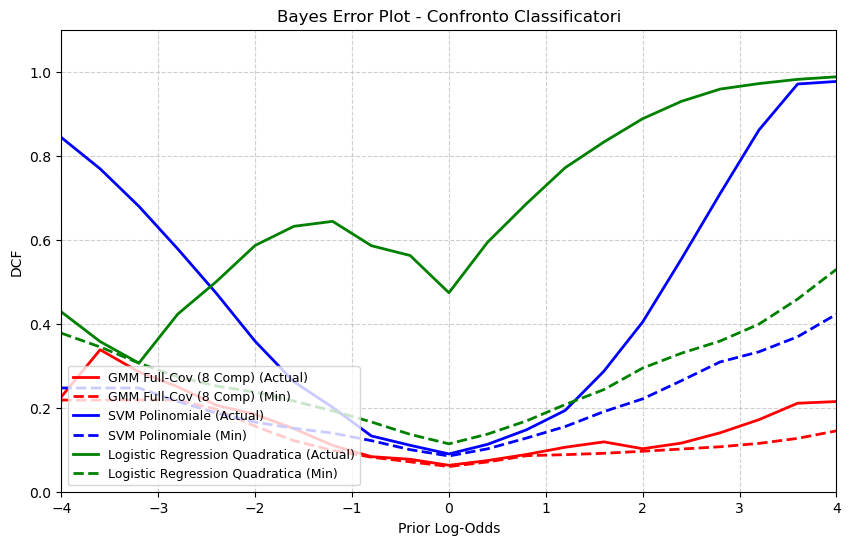

In [15]:
import numpy as np

llr_gmm_best=np.load('llr/score_gmm_best.npy')
score_lr_best = np.load('llr/score_lr_best.npy')
score_svm_best = np.load('llr/score_svm_best.npy')


llr_migliori = {
    'GMM Full-Cov (8 Comp)': llr_gmm_best,  
    'SVM Polinomiale': score_svm_best,
    'Logistic Regression Quadratica': score_lr_best
}

plot_bayes_error(llr_migliori, LVAL)